# ShieldShare Performance Analysis

This notebook analyzes performance data from ShieldShare VPN application.

## Data Structure
- **CPU CSV**: `timestamp_ms, cpu_pct` (app CPU usage percentage)
- **Battery CSV**: `timestamp_ms, battery_pct, is_charging`
- **Throughput CSV**: `timestamp_ms, upload_bps, download_bps, total_bytes_up, total_bytes_down`

## Graphs to Generate
1. CPU usage over time (Feedback point 11)
2. Battery usage over time (Feedback point 11)
3. Throughput (upload/download) over time
4. Jain's Fairness Index for throughput (Feedback point 9) - requires per-user data
5. Per-user throughput graphs (Feedback point 10) - requires per-user data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 1. Load Data

Load all CSV files from the Stats directory. Files are named with pattern:
- `battery-YYYYMMDD-HHMMSS.csv`
- `cpu-YYYYMMDD-HHMMSS.csv`
- `throughput-YYYYMMDD-HHMMSS.csv`


In [2]:
# CSV files are in the same directory as this notebook
STATS_DIR = Path(".")

def load_all_csvs(pattern):
    """Load all CSV files matching a pattern and combine them."""
    files = sorted(glob.glob(str(STATS_DIR / pattern)))
    if not files:
        print(f"No files found matching: {pattern}")
        return None
    
    dfs = []
    for file in files:
        try:
            df = pd.read_csv(file)
            # Extract session ID from filename
            session_id = Path(file).stem.split('-', 1)[1] if '-' in Path(file).stem else 'unknown'
            df['session_id'] = session_id
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")
    
    if not dfs:
        return None
    
    combined = pd.concat(dfs, ignore_index=True)
    return combined

# Load all data
cpu_df = load_all_csvs("cpu-*.csv")
battery_df = load_all_csvs("battery-*.csv")
throughput_df = load_all_csvs("throughput-*.csv")

print(f"CPU records: {len(cpu_df) if cpu_df is not None else 0}")
print(f"Battery records: {len(battery_df) if battery_df is not None else 0}")
print(f"Throughput records: {len(throughput_df) if throughput_df is not None else 0}")


CPU records: 180
Battery records: 180
Throughput records: 180


## 2. Process Timestamps

Convert timestamps from milliseconds to datetime and calculate relative time.


In [3]:
def process_timestamps(df, timestamp_col='timestamp_ms'):
    """Convert timestamps and add relative time."""
    if df is None or df.empty:
        return df
    
    df = df.copy()
    df['datetime'] = pd.to_datetime(df[timestamp_col], unit='ms')
    
    # Calculate relative time in minutes from start
    min_time = df['datetime'].min()
    df['time_minutes'] = (df['datetime'] - min_time).dt.total_seconds() / 60.0
    
    return df

if cpu_df is not None:
    cpu_df = process_timestamps(cpu_df)
if battery_df is not None:
    battery_df = process_timestamps(battery_df)
if throughput_df is not None:
    throughput_df = process_timestamps(throughput_df)

# Display sample data
if cpu_df is not None:
    print("\nCPU Data Sample:")
    print(cpu_df.head())
if battery_df is not None:
    print("\nBattery Data Sample:")
    print(battery_df.head())
if throughput_df is not None:
    print("\nThroughput Data Sample:")
    print(throughput_df.head())



CPU Data Sample:
    timestamp_ms    cpu_pct       session_id                datetime  \
0  1765207573578   0.000000  20251208-072613 2025-12-08 15:26:13.578   
1  1765207579023  65.149567  20251208-072613 2025-12-08 15:26:19.023   
2  1765207584049   8.339952  20251208-072624 2025-12-08 15:26:24.049   
3  1765207589753   7.374890  20251208-072624 2025-12-08 15:26:29.753   
4  1765207594788   5.961844  20251208-072624 2025-12-08 15:26:34.788   

   time_minutes  
0      0.000000  
1      0.090750  
2      0.174517  
3      0.269583  
4      0.353500  

Battery Data Sample:
    timestamp_ms  battery_pct  is_charging       session_id  \
0  1765207573578           18         True  20251208-072613   
1  1765207579023           18         True  20251208-072613   
2  1765207584049           18         True  20251208-072624   
3  1765207589753           18         True  20251208-072624   
4  1765207594788           18         True  20251208-072624   

                 datetime  time_minutes 

## 3. Graph 1: CPU Usage Over Time

**Requested in feedback point 11**: Show utilized CPU usage over time in a graph.


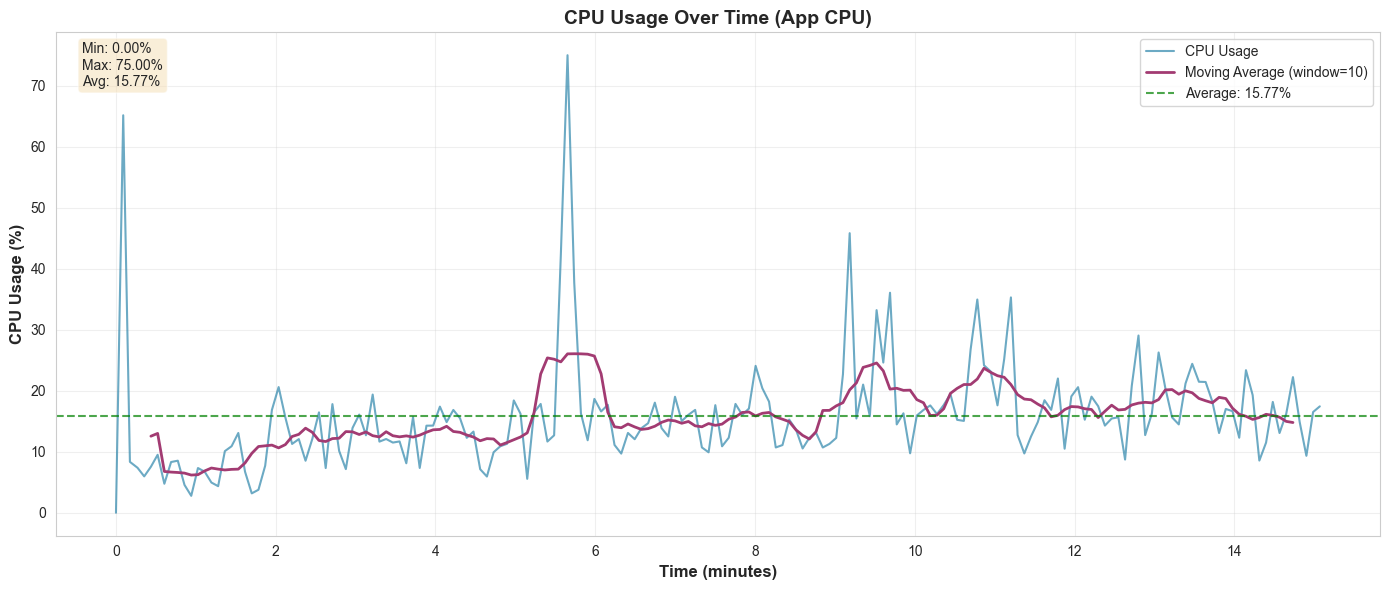


CPU Statistics:
  Average: 15.77%
  Maximum: 75.00%
  Minimum: 0.00%
  Std Dev: 9.01%


In [4]:
if cpu_df is not None and not cpu_df.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot CPU usage over time
    ax.plot(cpu_df['time_minutes'], cpu_df['cpu_pct'], 
            linewidth=1.5, alpha=0.7, color='#2E86AB', label='CPU Usage')
    
    # Add moving average for smoother trend
    window_size = min(10, len(cpu_df) // 10)
    if window_size > 1:
        cpu_df['cpu_ma'] = cpu_df['cpu_pct'].rolling(window=window_size, center=True).mean()
        ax.plot(cpu_df['time_minutes'], cpu_df['cpu_ma'], 
                linewidth=2, color='#A23B72', label=f'Moving Average (window={window_size})')
    
    # Calculate and display statistics
    avg_cpu = cpu_df['cpu_pct'].mean()
    max_cpu = cpu_df['cpu_pct'].max()
    min_cpu = cpu_df['cpu_pct'].min()
    
    ax.axhline(y=avg_cpu, color='green', linestyle='--', linewidth=1.5, 
               label=f'Average: {avg_cpu:.2f}%', alpha=0.7)
    
    ax.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
    ax.set_ylabel('CPU Usage (%)', fontsize=12, fontweight='bold')
    ax.set_title('CPU Usage Over Time (App CPU)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add text box with statistics
    stats_text = f'Min: {min_cpu:.2f}%\nMax: {max_cpu:.2f}%\nAvg: {avg_cpu:.2f}%'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('cpu_usage_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nCPU Statistics:")
    print(f"  Average: {avg_cpu:.2f}%")
    print(f"  Maximum: {max_cpu:.2f}%")
    print(f"  Minimum: {min_cpu:.2f}%")
    print(f"  Std Dev: {cpu_df['cpu_pct'].std():.2f}%")
else:
    print("No CPU data available.")


## 4. Graph 2: Battery Usage Over Time

**Requested in feedback point 11**: Show battery usage over time in a graph.


In [ ]:
if battery_df is not None and not battery_df.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Separate charging and discharging periods
    charging = battery_df[battery_df['is_charging'] == True]
    discharging = battery_df[battery_df['is_charging'] == False]
    
    # Plot battery level
    if not discharging.empty:
        ax.plot(discharging['time_minutes'], discharging['battery_pct'], 
                'o-', linewidth=2, markersize=4, color='#F18F01', 
                label='Discharging', alpha=0.7)
    
    if not charging.empty:
        ax.plot(charging['time_minutes'], charging['battery_pct'], 
                'o-', linewidth=2, markersize=4, color='#06A77D', 
                label='Charging', alpha=0.7)
    
    # Calculate battery drop rate
    if len(battery_df) > 1:
        total_time_hours = (battery_df['datetime'].max() - battery_df['datetime'].min()).total_seconds() / 3600
        battery_drop = battery_df['battery_pct'].iloc[0] - battery_df['battery_pct'].iloc[-1]
        if total_time_hours > 0:
            drop_per_hour = battery_drop / total_time_hours
            ax.text(0.98, 0.02, f'Battery Drop Rate: {drop_per_hour:.2f}%/hour', 
                   transform=ax.transAxes, fontsize=10, 
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    ax.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Battery Level (%)', fontsize=12, fontweight='bold')
    ax.set_title('Battery Usage Over Time', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 100])
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('battery_usage_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nBattery Statistics:")
    print(f"  Initial: {battery_df['battery_pct'].iloc[0]}%")
    print(f"  Final: {battery_df['battery_pct'].iloc[-1]}%")
    print(f"  Change: {battery_df['battery_pct'].iloc[-1] - battery_df['battery_pct'].iloc[0]:.2f}%")
    if len(battery_df) > 1:
        total_time_hours = (battery_df['datetime'].max() - battery_df['datetime'].min()).total_seconds() / 3600
        if total_time_hours > 0:
            print(f"  Duration: {total_time_hours:.2f} hours")
            print(f"  Drop Rate: {(battery_df['battery_pct'].iloc[0] - battery_df['battery_pct'].iloc[-1]) / total_time_hours:.2f}%/hour")
else:
    print("No battery data available.")


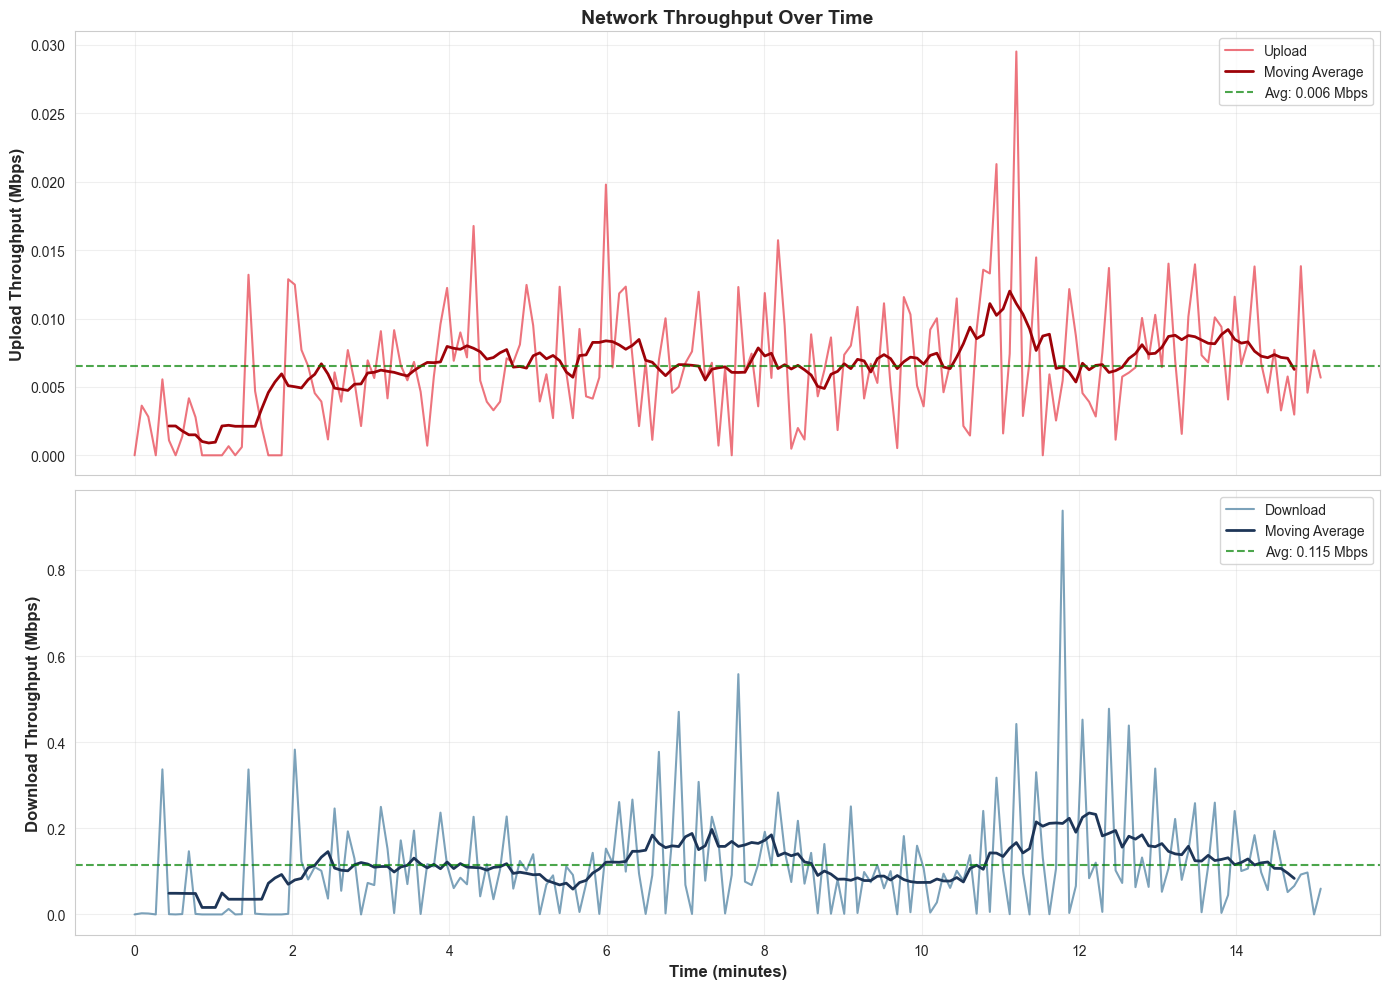


Throughput Statistics:
  Average Upload: 0.006 Mbps (6.50 Kbps)
  Average Download: 0.115 Mbps (115.45 Kbps)
  Peak Upload: 0.030 Mbps
  Peak Download: 0.938 Mbps
  Total Upload: 5.90 MB
  Total Download: 104.84 MB


In [5]:
if throughput_df is not None and not throughput_df.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Convert bps to Mbps for readability
    throughput_df['upload_mbps'] = throughput_df['upload_bps'] / 1_000_000
    throughput_df['download_mbps'] = throughput_df['download_bps'] / 1_000_000
    
    # Plot upload throughput
    ax1.plot(throughput_df['time_minutes'], throughput_df['upload_mbps'], 
             linewidth=1.5, alpha=0.7, color='#E63946', label='Upload')
    
    # Moving average for upload
    window_size = min(10, len(throughput_df) // 10)
    if window_size > 1:
        throughput_df['upload_ma'] = throughput_df['upload_mbps'].rolling(window=window_size, center=True).mean()
        ax1.plot(throughput_df['time_minutes'], throughput_df['upload_ma'], 
                 linewidth=2, color='#9D0208', label=f'Moving Average')
    
    avg_upload = throughput_df['upload_mbps'].mean()
    ax1.axhline(y=avg_upload, color='green', linestyle='--', linewidth=1.5, 
               label=f'Avg: {avg_upload:.3f} Mbps', alpha=0.7)
    
    ax1.set_ylabel('Upload Throughput (Mbps)', fontsize=12, fontweight='bold')
    ax1.set_title('Network Throughput Over Time', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot download throughput
    ax2.plot(throughput_df['time_minutes'], throughput_df['download_mbps'], 
             linewidth=1.5, alpha=0.7, color='#457B9D', label='Download')
    
    # Moving average for download
    if window_size > 1:
        throughput_df['download_ma'] = throughput_df['download_mbps'].rolling(window=window_size, center=True).mean()
        ax2.plot(throughput_df['time_minutes'], throughput_df['download_ma'], 
                 linewidth=2, color='#1D3557', label=f'Moving Average')
    
    avg_download = throughput_df['download_mbps'].mean()
    ax2.axhline(y=avg_download, color='green', linestyle='--', linewidth=1.5, 
               label=f'Avg: {avg_download:.3f} Mbps', alpha=0.7)
    
    ax2.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Download Throughput (Mbps)', fontsize=12, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('throughput_over_time.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nThroughput Statistics:")
    print(f"  Average Upload: {avg_upload:.3f} Mbps ({avg_upload*1000:.2f} Kbps)")
    print(f"  Average Download: {avg_download:.3f} Mbps ({avg_download*1000:.2f} Kbps)")
    print(f"  Peak Upload: {throughput_df['upload_mbps'].max():.3f} Mbps")
    print(f"  Peak Download: {throughput_df['download_mbps'].max():.3f} Mbps")
    print(f"  Total Upload: {throughput_df['total_bytes_up'].iloc[-1] / 1_000_000:.2f} MB")
    print(f"  Total Download: {throughput_df['total_bytes_down'].iloc[-1] / 1_000_000:.2f} MB")
else:
    print("No throughput data available.")


## 6. Combined Performance Overview

Show CPU, Battery, and Throughput together for comprehensive view.


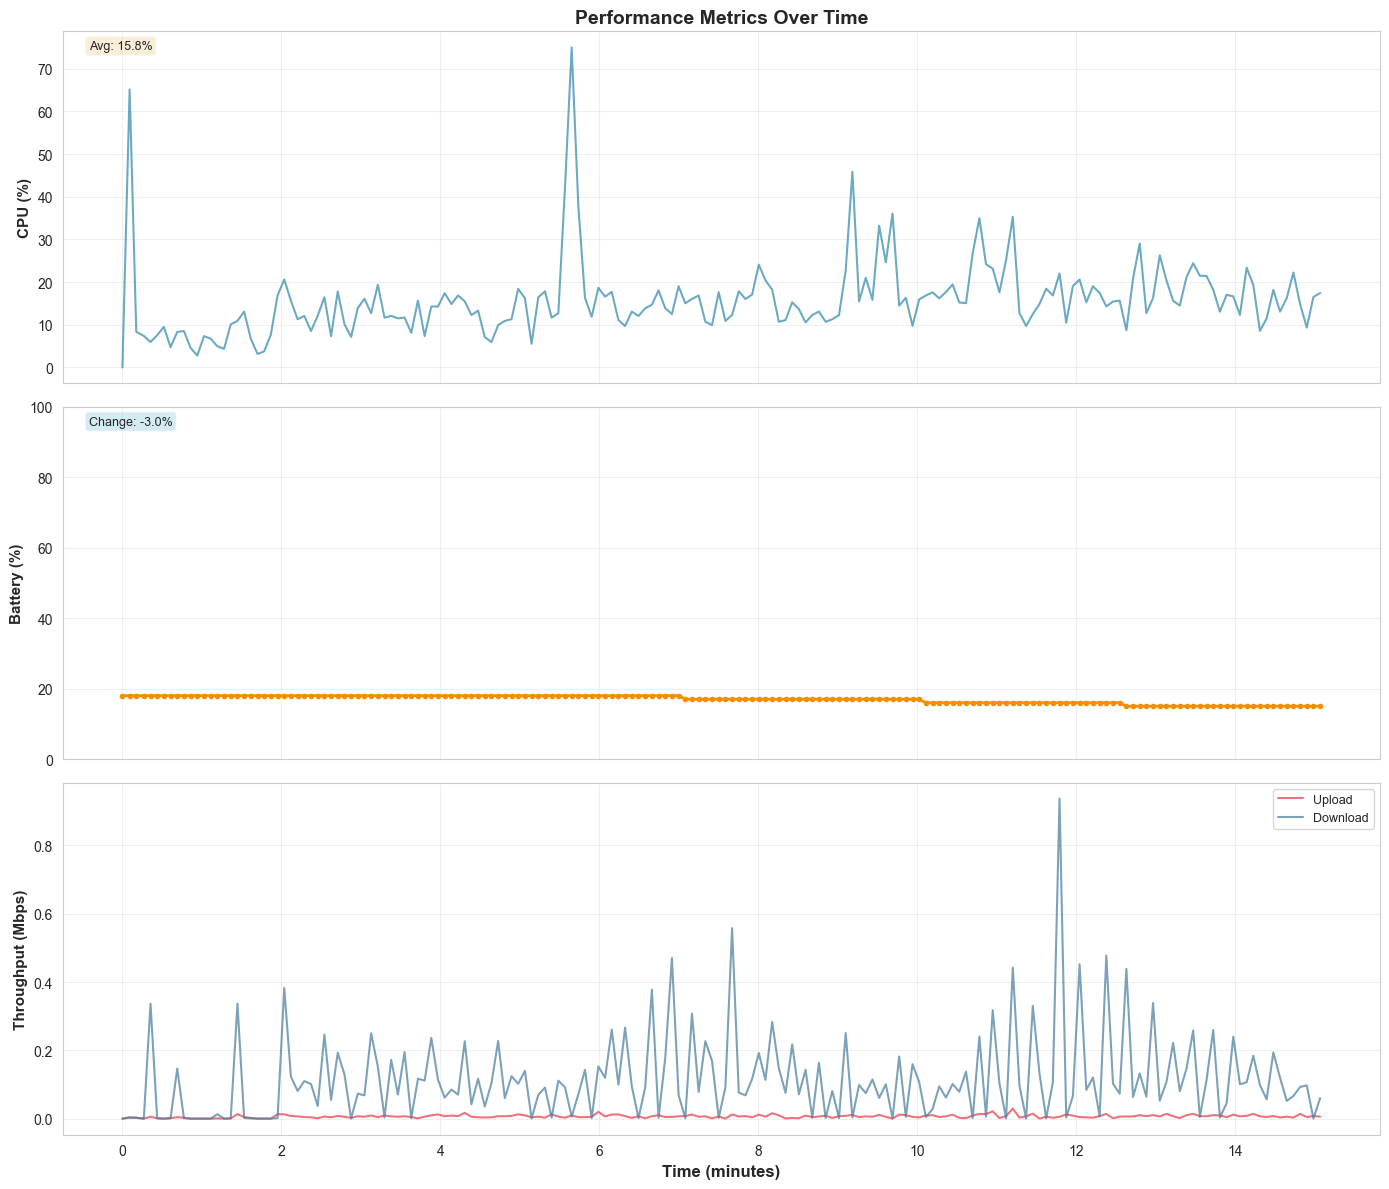

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# CPU
if cpu_df is not None and not cpu_df.empty:
    axes[0].plot(cpu_df['time_minutes'], cpu_df['cpu_pct'], 
                 linewidth=1.5, alpha=0.7, color='#2E86AB')
    axes[0].set_ylabel('CPU (%)', fontsize=11, fontweight='bold')
    axes[0].set_title('Performance Metrics Over Time', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, f"Avg: {cpu_df['cpu_pct'].mean():.1f}%", 
                transform=axes[0].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Battery
if battery_df is not None and not battery_df.empty:
    axes[1].plot(battery_df['time_minutes'], battery_df['battery_pct'], 
                 linewidth=2, color='#F18F01', marker='o', markersize=3)
    axes[1].set_ylabel('Battery (%)', fontsize=11, fontweight='bold')
    axes[1].set_ylim([0, 100])
    axes[1].grid(True, alpha=0.3)
    battery_change = battery_df['battery_pct'].iloc[-1] - battery_df['battery_pct'].iloc[0]
    axes[1].text(0.02, 0.95, f"Change: {battery_change:+.1f}%", 
                transform=axes[1].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Throughput
if throughput_df is not None and not throughput_df.empty:
    throughput_df['upload_mbps'] = throughput_df['upload_bps'] / 1_000_000
    throughput_df['download_mbps'] = throughput_df['download_bps'] / 1_000_000
    axes[2].plot(throughput_df['time_minutes'], throughput_df['upload_mbps'], 
                 linewidth=1.5, alpha=0.7, color='#E63946', label='Upload')
    axes[2].plot(throughput_df['time_minutes'], throughput_df['download_mbps'], 
                 linewidth=1.5, alpha=0.7, color='#457B9D', label='Download')
    axes[2].set_ylabel('Throughput (Mbps)', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
    axes[2].legend(loc='best', fontsize=9)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combined_performance_overview.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Jain's Fairness Index Calculation

**Requested in feedback point 9**: Calculate Jain's Fairness Index for throughput each user got.

**Note**: The current CSV files contain aggregate throughput data. To calculate per-user fairness, we need per-client throughput data. This section shows how to calculate it when per-user data is available.


In [7]:
def jains_fairness_index(throughputs):
    """
    Calculate Jain's Fairness Index.
    
    Formula: J(x1, x2, ..., xn) = (Σxi)² / (n * Σxi²)
    
    Returns a value between 1/n (worst case) and 1 (best case, perfectly fair).
    """
    if len(throughputs) == 0 or all(t == 0 for t in throughputs):
        return 0.0
    
    n = len(throughputs)
    sum_xi = sum(throughputs)
    sum_xi_squared = sum(x**2 for x in throughputs)
    
    if sum_xi_squared == 0:
        return 0.0
    
    jfi = (sum_xi ** 2) / (n * sum_xi_squared)
    return jfi

# Example calculation with sample data
# In real scenario, you would have per-user throughput data
print("Jain's Fairness Index Calculation")
print("=" * 50)
print("\nNote: Current CSV files contain aggregate throughput.")
print("For per-user fairness calculation, we need per-client throughput data.")
print("\nExample calculations:")

# Example 1: Perfectly fair (all users get same throughput)
fair_example = [10.0, 10.0, 10.0, 10.0]
jfi_fair = jains_fairness_index(fair_example)
print(f"\nExample 1 - Perfectly Fair (all users get 10 Mbps):")
print(f"  Throughputs: {fair_example}")
print(f"  Jain's Fairness Index: {jfi_fair:.4f}")

# Example 2: Unfair distribution
unfair_example = [1.0, 2.0, 5.0, 20.0]
jfi_unfair = jains_fairness_index(unfair_example)
print(f"\nExample 2 - Unfair Distribution:")
print(f"  Throughputs: {unfair_example}")
print(f"  Jain's Fairness Index: {jfi_unfair:.4f}")

# Example 3: Very unfair (one user dominates)
very_unfair_example = [0.1, 0.2, 0.3, 50.0]
jfi_very_unfair = jains_fairness_index(very_unfair_example)
print(f"\nExample 3 - Very Unfair (one user dominates):")
print(f"  Throughputs: {very_unfair_example}")
print(f"  Jain's Fairness Index: {jfi_very_unfair:.4f}")

print("\n" + "=" * 50)
print("\nTo calculate actual fairness for your tests:")
print("1. Export per-client throughput data from TrafficMeter")
print("2. Group by client IP/MAC address")
print("3. Calculate total throughput per client")
print("4. Apply Jain's Fairness Index formula")


Jain's Fairness Index Calculation

Note: Current CSV files contain aggregate throughput.
For per-user fairness calculation, we need per-client throughput data.

Example calculations:

Example 1 - Perfectly Fair (all users get 10 Mbps):
  Throughputs: [10.0, 10.0, 10.0, 10.0]
  Jain's Fairness Index: 1.0000

Example 2 - Unfair Distribution:
  Throughputs: [1.0, 2.0, 5.0, 20.0]
  Jain's Fairness Index: 0.4558

Example 3 - Very Unfair (one user dominates):
  Throughputs: [0.1, 0.2, 0.3, 50.0]
  Jain's Fairness Index: 0.2560


To calculate actual fairness for your tests:
1. Export per-client throughput data from TrafficMeter
2. Group by client IP/MAC address
3. Calculate total throughput per client
4. Apply Jain's Fairness Index formula


## 8. Per-User Throughput Analysis

**Requested in feedback point 10**: Show measured throughput per user (download/upload) as graphs or tables.

**Note**: This requires per-client throughput data. The current CSV files contain aggregate data. This section provides a template for when per-user data is available.


In [ ]:
print("Per-User Throughput Analysis")
print("=" * 50)
print("\nCurrent CSV files contain aggregate throughput data.")
print("To generate per-user throughput graphs, we need:")
print("  1. Per-client IP/MAC address")
print("  2. Per-client upload/download bytes")
print("  3. Timestamps for each client")
print("\nThis data can be obtained from:")
print("  - TrafficMeter.getCurrentStats() per client")
print("  - Database traffic_records table")
print("  - Client session data")
print("\n" + "=" * 50)
print("\nTemplate code for per-user analysis:")
print("""
# When per-user data is available:
# per_user_df = pd.read_csv('per_user_throughput.csv')
# per_user_df.columns = ['timestamp_ms', 'client_ip', 'upload_bps', 'download_bps']
# 
# # Group by client and calculate totals
# user_totals = per_user_df.groupby('client_ip').agg({
#     'upload_bps': 'sum',
#     'download_bps': 'sum'
# }).reset_index()
# 
# # Create bar chart
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# user_totals.plot(x='client_ip', y='upload_bps', kind='bar', ax=ax1)
# user_totals.plot(x='client_ip', y='download_bps', kind='bar', ax=ax2)
# 
# # Calculate Jain's Fairness Index
# upload_jfi = jains_fairness_index(user_totals['upload_bps'].tolist())
# download_jfi = jains_fairness_index(user_totals['download_bps'].tolist())
# """)


## 9. Summary Statistics Table

Generate summary statistics for all metrics.


In [8]:
summary_data = {}

if cpu_df is not None and not cpu_df.empty:
    summary_data['CPU (%)'] = {
        'Mean': f"{cpu_df['cpu_pct'].mean():.2f}",
        'Std Dev': f"{cpu_df['cpu_pct'].std():.2f}",
        'Min': f"{cpu_df['cpu_pct'].min():.2f}",
        'Max': f"{cpu_df['cpu_pct'].max():.2f}",
        'Median': f"{cpu_df['cpu_pct'].median():.2f}"
    }

if battery_df is not None and not battery_df.empty:
    battery_change = battery_df['battery_pct'].iloc[-1] - battery_df['battery_pct'].iloc[0]
    total_time_hours = (battery_df['datetime'].max() - battery_df['datetime'].min()).total_seconds() / 3600
    drop_rate = battery_change / total_time_hours if total_time_hours > 0 else 0
    summary_data['Battery (%)'] = {
        'Initial': f"{battery_df['battery_pct'].iloc[0]:.1f}",
        'Final': f"{battery_df['battery_pct'].iloc[-1]:.1f}",
        'Change': f"{battery_change:+.1f}",
        'Duration (hrs)': f"{total_time_hours:.2f}",
        'Drop Rate (%/hr)': f"{drop_rate:.2f}"
    }

if throughput_df is not None and not throughput_df.empty:
    summary_data['Upload (Mbps)'] = {
        'Mean': f"{throughput_df['upload_bps'].mean() / 1_000_000:.3f}",
        'Peak': f"{throughput_df['upload_bps'].max() / 1_000_000:.3f}",
        'Total (MB)': f"{throughput_df['total_bytes_up'].iloc[-1] / 1_000_000:.2f}"
    }
    summary_data['Download (Mbps)'] = {
        'Mean': f"{throughput_df['download_bps'].mean() / 1_000_000:.3f}",
        'Peak': f"{throughput_df['download_bps'].max() / 1_000_000:.3f}",
        'Total (MB)': f"{throughput_df['total_bytes_down'].iloc[-1] / 1_000_000:.2f}"
    }

if summary_data:
    summary_df = pd.DataFrame(summary_data).T
    print("\nSummary Statistics")
    print("=" * 80)
    print(summary_df.to_string())
    
    # Save to CSV
    summary_df.to_csv('summary_statistics.csv')
    print("\nSummary saved to 'summary_statistics.csv'")



Summary Statistics
                  Mean Std Dev   Min    Max Median Initial Final Change Duration (hrs) Drop Rate (%/hr)   Peak Total (MB)
CPU (%)          15.77    9.01  0.00  75.00  14.94     NaN   NaN    NaN            NaN              NaN    NaN        NaN
Battery (%)        NaN     NaN   NaN    NaN    NaN    18.0  15.0   -3.0           0.25           -11.94    NaN        NaN
Upload (Mbps)    0.006     NaN   NaN    NaN    NaN     NaN   NaN    NaN            NaN              NaN  0.030       5.90
Download (Mbps)  0.115     NaN   NaN    NaN    NaN     NaN   NaN    NaN            NaN              NaN  0.938     104.84

Summary saved to 'summary_statistics.csv'


## Notes and Next Steps

1. **CPU and Battery graphs** (point 11) - Generated above
2. **Jain's Fairness Index** (point 9) - Requires per-user throughput data
3. **Per-user throughput graphs** (point 10) - Requires per-client data export

### To get per-user data:
- Export per-client statistics from `TrafficMeter.getCurrentStats()`
- Query `traffic_records` table grouped by `clientIp`
- Add per-client CSV export to `PerformanceMonitor` if needed

### File Outputs:
- `cpu_usage_over_time.png`
- `battery_usage_over_time.png`
- `throughput_over_time.png`
- `combined_performance_overview.png`
- `summary_statistics.csv`
